<a href="https://colab.research.google.com/github/indawulan/Portofolio/blob/main/ANALIS_DATA_KELAS_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== PREVIEW DATA ===


,Timestamp,Judul Video,Views,Likes,Komentar,Durasi,Kategori
0,Timestamp,Judul Video,Views,Likes,Komentar,Durasi,Kategori
1,2026-05-01 8:15:00,Tips Makeup Natural,120000,8500,320,30,Beauty
2,2026-05-01 9:20:00,Gameplay Mobile Legends Epic,250000,15000,820,45,Game
3,2026-05-01 10:05:00,Cara Cepat Belajar Matematika,90000,5000,210,60,Edukasi
4,2026-05-01 11:30:00,Dance Challenge Viral,320000,21000,950,20,Hiburan



Nama Kolom: Index(['Timestamp', 'Judul Video', 'Views', 'Likes', 'Komentar', 'Durasi',
       'Kategori'],
      dtype='object')

=== STATISTIK ===
Rata-rata Views: 173500
Rata-rata Likes: 11110

=== TOP 5 VIDEO PALING VIRAL ===


,Judul Video,Views
4,Dance Challenge Viral,320000.0
6,Prank Teman Sekelas,275000.0
2,Gameplay Mobile Legends Epic,250000.0
10,Highlight Game Lucu,210000.0
8,Unboxing Gadget Terbaru,150000.0


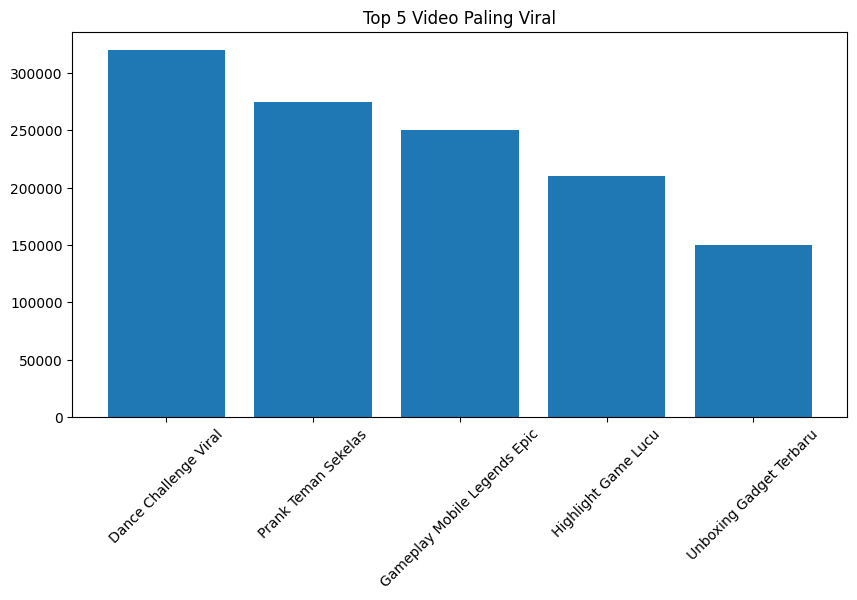


=== RATA-RATA VIEWS PER KATEGORI ===
Kategori
Beauty     125000
Edukasi     85000
Game       230000
Hiburan    297500
Review     130000
Name: Views, dtype: int64


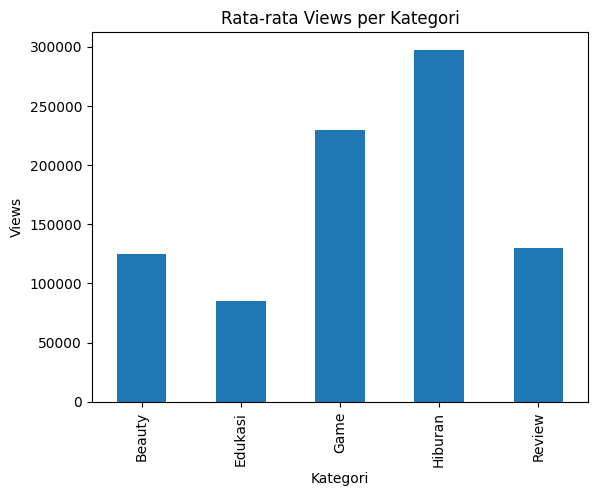


=== ENGAGEMENT TERTINGGI ===


,Judul Video,Engagement (%)
1,Tips Makeup Natural,7%
9,Tutorial Hijab Simple,7%
10,Highlight Game Lucu,7%
4,Dance Challenge Viral,7%
6,Prank Teman Sekelas,7%



=== HUBUNGAN DATA ===
          Views  Likes  Komentar
Views      1.00   0.99      0.99
Likes      0.99   1.00      0.98
Komentar   0.99   0.98      1.00


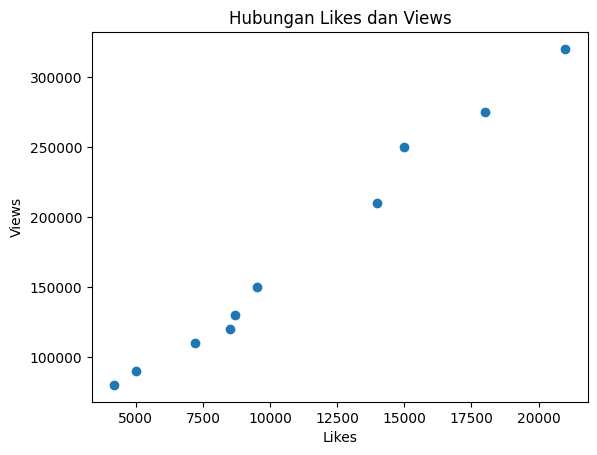


=== KESIMPULAN ===
Kategori paling viral: Hiburan
Video paling viral: Dance Challenge Viral

=== ANALISIS SISWA ===
1. Kenapa kategori ini paling viral?
2. Apakah likes mempengaruhi views?
3. Durasi ideal menurut data?
4. Strategi konten viral menurutmu?


In [4]:
# ==========================================
# ANALISIS KONTEN VIRAL (DENGAN PENJELASAN)
# ==========================================

# 📌 Import library
# pandas = untuk mengolah data seperti Excel
# matplotlib = untuk membuat grafik
import pandas as pd
import matplotlib.pyplot as plt


# ==========================================
# 📥 LOAD DATA
# ==========================================

# 👉 link Google Sheets dari form
url = "https://docs.google.com/spreadsheets/d/1i5JNH1p7g7KtSC5XjPmlNG7FkcX9iNb627BERMAlj08/export?format=csv"

# Membaca data dari link ke dalam variabel df
df = pd.read_csv(url)

# Menampilkan 5 data pertama (preview)
print("=== PREVIEW DATA ===")
display(df.head())


# ==========================================
# 🧹 MEMBERSIHKAN KOLOM
# ==========================================

# Menghapus spasi yang tidak terlihat di nama kolom
df.columns = [col.strip() for col in df.columns]

# Menampilkan nama kolom untuk memastikan
print("\nNama Kolom:", df.columns)


# ==========================================
# 🔢 UBAH DATA KE ANGKA
# ==========================================

# Mengubah kolom menjadi angka
# Jika ada data yang salah → akan jadi kosong (NaN)
df["Views"] = pd.to_numeric(df["Views"], errors='coerce')
df["Likes"] = pd.to_numeric(df["Likes"], errors='coerce')
df["Komentar"] = pd.to_numeric(df["Komentar"], errors='coerce')
df["Durasi"] = pd.to_numeric(df["Durasi"], errors='coerce')

# Menghapus data kosong agar tidak mengganggu analisis
df = df.dropna()


# ==========================================
# 📊 STATISTIK DASAR
# ==========================================

print("\n=== STATISTIK ===")

# Menghitung rata-rata (dibulatkan agar mudah dipahami)
rata_views = int(df["Views"].mean())
rata_likes = int(df["Likes"].mean())

print("Rata-rata Views:", rata_views)
print("Rata-rata Likes:", rata_likes)


# ==========================================
# 🔥 TOP VIDEO PALING VIRAL
# ==========================================

print("\n=== TOP 5 VIDEO PALING VIRAL ===")

# Mengurutkan berdasarkan Views (tertinggi ke terendah)
top5 = df.sort_values(by="Views", ascending=False).head(5)

# Menampilkan judul dan views saja
display(top5[["Judul Video", "Views"]])


# ==========================================
# 📈 GRAFIK VIEWS
# ==========================================

plt.figure(figsize=(10,5))

# Membuat grafik batang
plt.bar(top5["Judul Video"], top5["Views"])

plt.title("Top 5 Video Paling Viral")
plt.xticks(rotation=45)  # agar tulisan tidak bertumpuk

plt.show()


# ==========================================
# 📊 ANALISIS KATEGORI
# ==========================================

print("\n=== RATA-RATA VIEWS PER KATEGORI ===")

# Mengelompokkan berdasarkan kategori
kategori = df.groupby("Kategori")["Views"].mean()

# Dibulatkan agar mudah dibaca
kategori = kategori.round(0).astype(int)

print(kategori)

# Grafik kategori
plt.figure()
kategori.plot(kind="bar")
plt.title("Rata-rata Views per Kategori")
plt.ylabel("Views")
plt.show()


# ==========================================
# ❤️ ENGAGEMENT (DAYA TARIK KONTEN)
# ==========================================

# Kolom angka (untuk perhitungan)
df["Engagement_num"] = (df["Likes"] / df["Views"]) * 100

# Kolom persen
df["Engagement (%)"] = df["Engagement_num"].round(0).astype(int).astype(str) + "%"

print("\n=== ENGAGEMENT TERTINGGI ===")
display(df.sort_values(by="Engagement_num", ascending=False)[["Judul Video", "Engagement (%)"]].head())



# ==========================================
# 🔗 HUBUNGAN DATA (KORELASI)
# ==========================================

print("\n=== HUBUNGAN DATA ===")

# Melihat hubungan antara Views, Likes, Komentar
print(df[["Views", "Likes", "Komentar"]].corr().round(2))


# ==========================================
# 📍 GRAFIK HUBUNGAN
# ==========================================

plt.figure()

# Scatter plot untuk melihat hubungan Likes dan Views
plt.scatter(df["Likes"], df["Views"])

plt.title("Hubungan Likes dan Views")
plt.xlabel("Likes")
plt.ylabel("Views")

plt.show()


# ==========================================
# 🧠 KESIMPULAN OTOMATIS
# ==========================================

# Kategori dengan views tertinggi
kategori_terbaik = kategori.idxmax()

# Video paling viral
video_terbaik = top5.iloc[0]["Judul Video"]

print("\n=== KESIMPULAN ===")
print("Kategori paling viral:", kategori_terbaik)
print("Video paling viral:", video_terbaik)


# ==========================================
# ❓ PERTANYAAN UNTUK SISWA
# ==========================================

print("\n=== ANALISIS SISWA ===")
print("1. Kenapa kategori ini paling viral?")
print("2. Apakah likes mempengaruhi views?")
print("3. Durasi ideal menurut data?")
print("4. Strategi konten viral menurutmu?")